# F.A. Maringá

## Análise do faturamento

Neste notebook vou aprofundar no desenvolvimento da análise do faturamento de uma das empresa do grupo F.A. 

A base de dados para essa análise são dois arquivos: 

- ```FIS_NF.csv```: Contém o cabeçalho de notas fiscais emitidas no mês de março de 2026.
  
- ```FIS_NFITEM.csv```: Contém a descrição das notas fiscais emitidas, com detalhes de cada item presente nas notas. 

Cada um desses arquivos já foi devidamente tratado, e com seus dados padronizados e salvos nas seguintes versōes:

- ```NF.csv```

- ```NFITEM.csv```

## Análises mínimas esperadas

O relatório deverá apresentar, no mínimo:

- Faturamento bruto;
- Faturamento líquido;
- Valor de descontos;
- Quantidade faturada;
- Quantidade de notas fiscais distintas;
- Ticket médio por nota fiscal;
- Evolução diária do faturamento;
- Faturamento por empresa;
- Principais produtos por faturamento;
- Principais produtos por quantidade faturada.


## Contexto dos dados

A análise exploratória que foi feita em cada um desses arquivos foi crucial para a compreensão da base de dados, assim como do problema de negócio. 

Foi possível obter insights fundamentais para o desenvolvimento dessa análise principal.

```NF```: 
- 'TP_SITUACAO' e 'CD_OPERACAO' mostram um claro indicativo do comportamento dos dados.
- Colunas com os valores estão muito bem definidas e são auto explicativas. Fundamentais para o cálculo do faturamento. 

```NFITEM```:
- 'CD_CST', 'CD_CFOP', 'CD_TIPI' são peças de extrema importância para o entendimento fiscal e a definição do que entra e o que não entra no faturamento. Foram a base para o desenvolvimento de várias novas colunas/indicadores para essa base de dados.
- Colunas com os valores apresentam detalhes maiores do que a base de dados```NF```. 

## Respondendo perguntas

### O que é faturamento?

Faturamento é o valor total gerado pelas vendas de produtos ou pela prestação de serviços de uma empresa em determinado período, normalmente apurado a partir das notas fiscais emitidas.

Em termos simples:

- Faturamento: valor das vendas realizadas antes da dedução de impostos, devoluções, cancelamentos, descontos e demais abatimentos.

#### Regra contábil central

Cada item fiscal deve ser classificado em uma destas categorias:

| Classificação                   | Tratamento                                           |
| ------------------------------- | ---------------------------------------------------- |
| Venda válida para terceiro      | Soma no faturamento                                  |
| Devolução de venda recebida     | Reduz o faturamento líquido                          |
| Entrada de compra ou serviço    | Não é faturamento                                    |
| Transferência entre filiais     | Não é faturamento                                    |
| Remessa ou retorno              | Não é faturamento                                    |
| Bonificação, doação ou brinde   | Não é faturamento                                    |
| Uso e consumo                   | Não é faturamento                                    |
| Ativo imobilizado               | Não é faturamento                                    |
| Nota cancelada ou excluída      | Desconsiderar completamente                          |
| Venda intercompany              | Inclui na empresa individual; elimina no consolidado |
| Ajuste fiscal ou administrativo | Não é faturamento operacional                        |


A classificação deve combinar:

- situação do documento.
- direção da nota.
- direção do CFOP.
- tipo de operação do CFOP.
- tipo fiscal do item.

--- 

Agora que ficou claro o que é faturamento, e que a base de dados fornece todos os dados necessários para calcular o faturamento. 

Vamos iniciar a análise.

---

# Iniciando análise

In [1]:
%matplotlib inline
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path().cwd().parent / "data"

In [2]:
# Importando cabeçalho da Nota Fiscal
df_nf = pd.read_csv(DATA_DIR / 'NF.csv')

# Importando Itens da Nota Fiscal
df_item = pd.read_csv(DATA_DIR / 'NFITEM.csv')

In [3]:
df_nf.head()

In [4]:
df_item.head()

In [5]:
df_nf.columns

Index(['CD_EMPRESA', 'NR_FATURA', 'DT_FATURA', 'CD_PESSOA', 'CD_EMPFAT',
       'CD_GRUPOEMPRESA', 'CD_OPERADOR', 'DT_CADASTRO', 'NR_NF', 'CD_SERIE',
       'DT_EMISSAO', 'TP_ORIGEMEMISSAO', 'TP_MODDCTOFISCAL', 'TP_OPERACAO',
       'TP_SITUACAO', 'CD_EMPRESAORI', 'NR_TRANSACAOORI', 'CD_OPERACAO',
       'CD_CONDPGTO', 'HR_SAIDA', 'DT_SAIDAENTRADA', 'CD_COMPVEND',
       'PR_DESCONTO', 'QT_FATURADO', 'VL_TOTALPRODUTO', 'VL_DESPACESSOR',
       'VL_FRETE', 'VL_SEGURO', 'VL_IPI', 'VL_DESCONTO', 'VL_TOTALNOTA',
       'VL_BASEICMSSUBS', 'VL_ICMSSUBST', 'VL_BASEICMS', 'VL_ICMS'],
      dtype='str')

In [6]:
df_item.columns

Index(['CD_EMPRESA', 'NR_FATURA', 'DT_FATURA', 'NR_ITEM', 'U_VERSION',
       'CD_EMPFAT', 'CD_GRUPOEMPRESA', 'CD_OPERADOR', 'DT_CADASTRO', 'CD_TIPI',
       'CD_CFOP', 'CD_PRODUTO', 'CD_ESPECIE', 'CD_CST', 'IN_DESCONTO',
       'PR_DESCONTO', 'DS_PRODUTO', 'QT_FATURADO', 'VL_TOTALBRUTO',
       'VL_TOTALDESC', 'VL_TOTALLIQUIDO', 'VL_UNITBRUTO', 'VL_UNITDESC',
       'VL_UNITLIQUIDO', 'VL_DESPACESSOR', 'VL_FRETE', 'VL_SEGURO',
       'ORIGEM_MERCADORIA', 'CST_ICMS', 'ORIGEM_DESC', 'CST_ICSM_DESC',
       'CST_GRUPO', 'CFOP_PREFIXO', 'CFOP_GRUPO_BASE', 'CFOP_TIPO_FLUXO',
       'CFOP_ABRANGENCIA', 'CFOP_CLASSE_GERAL', 'CFOP_TIPO_OPERACAO',
       'TIPI_CAPITULO', 'TIPI_POSICAO', 'TIPI_SUBPOSICAO', 'TIPI_ITEM',
       'TIPI_GRUPO_FISCAL', 'TIPI_TIPO_PRODUTO', 'TIPI_FAMILIA_COMERCIAL',
       'TIPI_VALIDO', 'TIPO_ITEM_FISCAL'],
      dtype='str')

## Aplicando filtros

Como mencionado anteriormente, nem tudo faz parte do cálculo do faturamento de uma empresa. Dessa forma vai ser necessário desenvolver um segundo tratamento na base de dados, separar tudo aquilo que entra do que não entra no cálculo do faturamento.

### df_nf | NF.csv

Para iniciar a nova etapa de tratamento, vou utilizar o dataframe com o cabeçalho das notas.

### Separando notas fiscais válidas

A coluna 'TP_SITUACAO' contém os seguintes registros:

- 'E' : Efetivada
- 'C' : Cancelada
- 'X' : Excluída

Para o cálculo do faturamento somente notas válidas (E) são consideradas.

In [7]:
df_nf_valido = df_nf[
    df_nf['TP_SITUACAO'].eq("E")
    ].copy()
print('Quantidade de notas antes do filtro:\t',df_nf.shape[0])
print('Quantidade de notas após o filtro:\t',df_nf_valido.shape[0])

Quantidade de notas antes do filtro:	 35414
Quantidade de notas após o filtro:	 34466


In [8]:
# Conferindo o fluxo
df_nf_valido["TP_OPERACAO"].value_counts(dropna=False)

TP_OPERACAO
E    18163
S    16303
Name: count, dtype: int64

In [9]:
df_nf_valido[df_nf_valido["TP_OPERACAO"] == "S"]

### Definir a chave da Nota Fiscal

Para contar notas distintas, não posso usar somente NR_NF, uma vez que mesma numeração pode existir em empresas diferentes.


In [10]:
CHAVE_NF = [
    "CD_EMPFAT",
    "CD_SERIE",
    "NR_NF",
]

df_nf_valido["ID_NOTA"] = (
    df_nf_valido["CD_EMPFAT"].astype(str)
    + "."
    + df_nf_valido["CD_SERIE"].astype(str)
    + "."
    + df_nf_valido["NR_NF"].astype(str)
)

# Verificando duplicidades
print(
    "Quantidade de notas duplicadas", 
    df_nf_valido["ID_NOTA"].duplicated().sum()
    )

Quantidade de notas duplicadas 5


Conferindo notas duplicadas e seus itens.

In [11]:
duplicadas = df_nf_valido[
    df_nf_valido.duplicated(
        CHAVE_NF,
        keep=False
    )
].sort_values(CHAVE_NF)

duplicadas.T

In [12]:
CHAVE_DOCUMENTO = [
    "CD_EMPRESA",
    "CD_EMPFAT",
    "NR_FATURA",
    "DT_FATURA",
]

chaves_duplicadas = (
    duplicadas[CHAVE_DOCUMENTO]
    .drop_duplicates()
)

itens_notas_duplicadas = df_item.merge(
    chaves_duplicadas,
    on=CHAVE_DOCUMENTO,
    how="inner",
    validate="many_to_one",
)

itens_notas_duplicadas.T

O resultado mostra que os dez registros relacionados às cinco chaves duplicadas são todos itens de entrada, classificados como aquisição de serviços, aquisição de transporte ou uso e consumo, portanto, não são vendas.

O que provavelmente causou as cinco duplicidades?

A chave utilizada geralmente funciona para notas de saída, porque uma empresa emissora não deveria repetir o mesmo número e série.

Para notas de entrada, porém, o mesmo número pode ser utilizado por fornecedores diferentes.

No contexto das métricas de faturamento, essas cinco duplicidades provavelmente não constituem problema, pois todos os itens analisados são de entrada e não participarão da contagem das notas de venda.

### Definir a data oficial do relatório

A data base para esse relatório vai ser a Data de Emissão pelos seguintes motivos:

- Contém o histórico do mês fiscal de março.
- Data que determina o fluxo financeiro contábil.

In [13]:
df_nf_valido["DT_EMISSAO"] = pd.to_datetime(df_nf_valido["DT_EMISSAO"],errors="coerce",).dt.normalize()

### df_item | NFITEM.csv

Agora vou iniciar o novo tratamento no dataframe com os itens das notas fiscais.

A primeira operação deve ser manter somente os itens pertencentes às notas efetivadas de df_nf_valido.

In [14]:
colunas_nf = CHAVE_DOCUMENTO + [
    "NR_NF",
    "CD_SERIE",
    "DT_EMISSAO",
    "CD_PESSOA",
    "TP_OPERACAO",
]

df_item_valido = df_item.merge(
    df_nf_valido[colunas_nf],
    on=CHAVE_DOCUMENTO,
    how="inner",
    validate="many_to_one",
)

print("Quantidade de registros antes do filtro:",df_item.shape[0])
print("Quantidade de registros após o filtro:\t",df_item_valido.shape[0])

Quantidade de registros antes do filtro: 49614
Quantidade de registros após o filtro:	 48248


In [15]:
df_item_valido.T

O próximo passo é validar se o fluxo fiscal dos itens está consistente com o tipo de operação informado no cabeçalho.

In [16]:
pd.crosstab(
    df_item_valido["TP_OPERACAO"],
    df_item_valido["CFOP_TIPO_FLUXO"],
    margins=True
)

In [17]:
pd.crosstab(
    df_item_valido["CFOP_TIPO_OPERACAO"],
    df_item_valido["TP_OPERACAO"],
    margins=True
).sort_values("All", ascending=False)

In [18]:
distribuicao_operacoes = (
    df_item_valido
    .groupby(
        ["TP_OPERACAO", "CFOP_TIPO_OPERACAO"],
        dropna=False
    )
    .agg(
        quantidade_itens=("NR_ITEM", "size"),
        valor_bruto=("VL_TOTALBRUTO", "sum"),
        descontos=("VL_TOTALDESC", "sum"),
        valor_liquido=("VL_TOTALLIQUIDO", "sum"),
        quantidade_faturada=("QT_FATURADO", "sum"),
    )
    .reset_index()
    .sort_values(
        ["TP_OPERACAO", "valor_liquido"],
        ascending=[True, False]
    )
)

distribuicao_operacoes

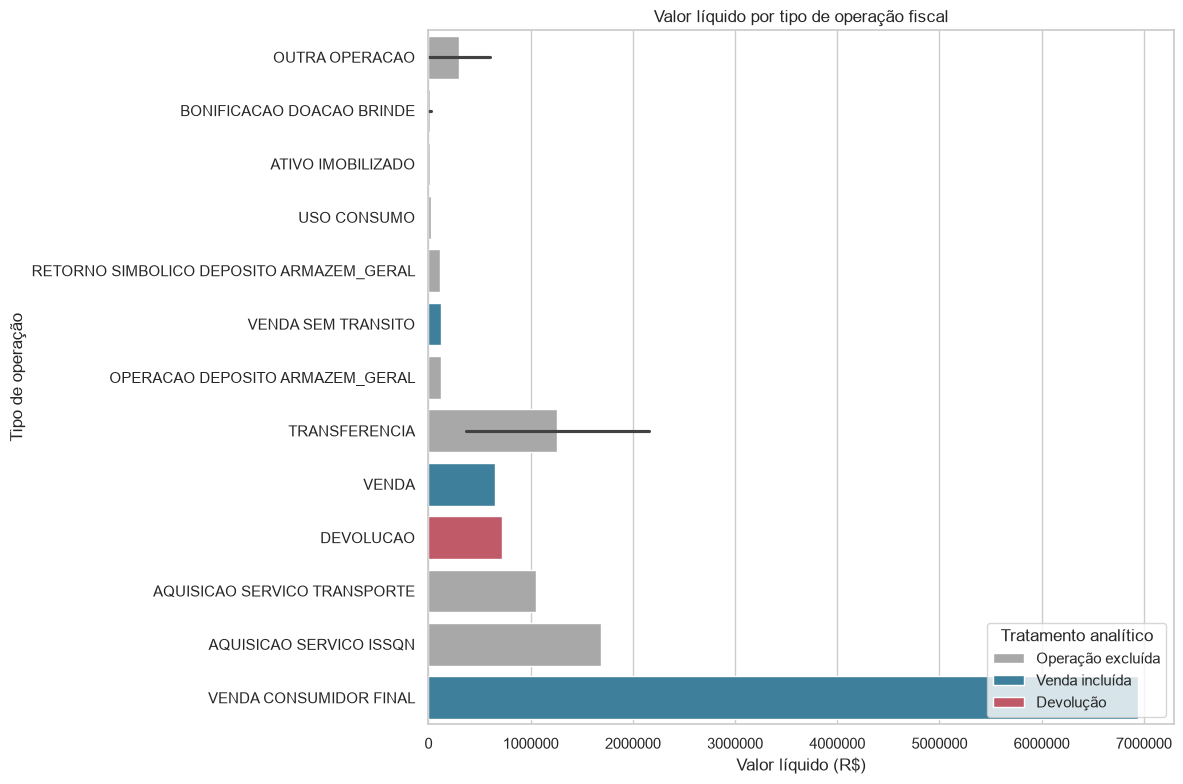

In [19]:
# Valor líquido por natureza fiscal: vendas, devoluções e operações excluídas.
operacoes_plot = distribuicao_operacoes.copy()
operacoes_plot["classificacao"] = np.select(
    [
        operacoes_plot["CFOP_TIPO_OPERACAO"].isin([
            "VENDA", "VENDA CONSUMIDOR FINAL", "VENDA SEM TRANSITO"
        ]),
        operacoes_plot["CFOP_TIPO_OPERACAO"].eq("DEVOLUCAO"),
    ],
    ["Venda incluída", "Devolução"],
    default="Operação excluída",
)
operacoes_plot = operacoes_plot.sort_values("valor_liquido")

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=operacoes_plot,
    x="valor_liquido",
    y="CFOP_TIPO_OPERACAO",
    hue="classificacao",
    dodge=False,
    palette={
        "Venda incluída": "#2E86AB",
        "Devolução": "#D1495B",
        "Operação excluída": "#A8A8A8",
    },
    ax=ax,
)
ax.set(
    title="Valor líquido por tipo de operação fiscal",
    xlabel="Valor líquido (R$)",
    ylabel="Tipo de operação",
)
ax.legend(title="Tratamento analítico", loc="lower right")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

A distribuição permite definir com segurança quais itens representam venda faturada.

As operações geradoras de faturamento são:

- VENDA
- VENDA CONSUMIDOR FINAL
- VENDA SEM TRANSITO

Todas elas aparecem exclusivamente como saída, então não é necessário repetir o filtro por TP_OPERACAO == "S".

In [20]:
operacoes_venda = [
    "VENDA",
    "VENDA CONSUMIDOR FINAL",
    "VENDA SEM TRANSITO",
]

# Criando df com itens de venda
df_item_venda = df_item_valido[df_item_valido["CFOP_TIPO_OPERACAO"].isin(operacoes_venda)].copy()

print("Quantidade de itens de venda:", df_item_venda.shape[0])

df_item_venda[
    [
        "VL_TOTALBRUTO",
        "VL_TOTALDESC",
        "VL_TOTALLIQUIDO",
        "QT_FATURADO",
    ]
].sum()

Quantidade de itens de venda: 21588


VL_TOTALBRUTO      7725855.07
VL_TOTALDESC          2375.21
VL_TOTALLIQUIDO    7723479.86
QT_FATURADO          25110.00
dtype: float64

In [21]:
df_item_venda.groupby(
    "CFOP_TIPO_OPERACAO"
).agg(
    quantidade_itens=("NR_ITEM", "size"),
    valor_bruto=("VL_TOTALBRUTO", "sum"),
    descontos=("VL_TOTALDESC", "sum"),
    valor_liquido=("VL_TOTALLIQUIDO", "sum"),
    quantidade_faturada=("QT_FATURADO", "sum"),
)

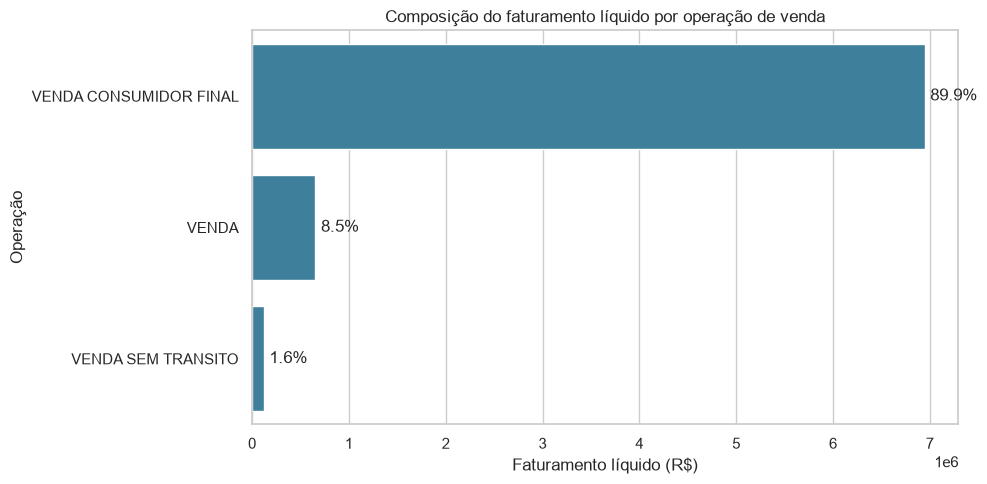

In [22]:
# Composição do faturamento entre as três operações de venda elegíveis.
mix_vendas = (
    df_item_venda.groupby("CFOP_TIPO_OPERACAO", as_index=False)
    .agg(faturamento_liquido=("VL_TOTALLIQUIDO", "sum"))
    .sort_values("faturamento_liquido", ascending=False)
)
mix_vendas["participacao"] = (
    mix_vendas["faturamento_liquido"] / mix_vendas["faturamento_liquido"].sum()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=mix_vendas,
    x="faturamento_liquido",
    y="CFOP_TIPO_OPERACAO",
    color="#2E86AB",
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{p:.1%}" for p in mix_vendas["participacao"]],
        padding=4,
    )
ax.set(
    title="Composição do faturamento líquido por operação de venda",
    xlabel="Faturamento líquido (R$)",
    ylabel="Operação",
)
plt.tight_layout()
plt.show()

### Operações excluídas do faturamento bruto

Não entram em df_item_venda:

- TRANSFERENCIA.
- AQUISICAO SERVICO TRANSPORTE.
- AQUISICAO SERVICO ISSQN.
- RETORNO SIMBOLICO DEPOSITO ARMAZEM_GERAL.
- OPERACAO DEPOSITO ARMAZEM_GERAL.
- BONIFICACAO DOACAO BRINDE.
- USO CONSUMO.
- ATIVO IMOBILIZADO.
- OUTRA OPERACAO.
- DEVOLUCAO.

Esses registros ficam fora do subconjunto de vendas.

A operação 'OUTRA OPERACAO' de entrada merece auditoria separada, pois contém somente dois itens, mas soma aproximadamente R$ 603 mil. Por enquanto, ela não deve ser classificada como faturamento.

O próximo passo é isolar as devoluções de clientes, sem ainda descontá-las do faturamento.

In [23]:
df_item_devolucao = df_item_valido[
    df_item_valido["CFOP_TIPO_OPERACAO"].eq("DEVOLUCAO")
    ].copy()


df_item_devolucao.groupby(
    "TIPO_ITEM_FISCAL",
    dropna=False
).agg(
    quantidade_itens=("NR_ITEM", "size"),
    valor_bruto=("VL_TOTALBRUTO", "sum"),
    descontos=("VL_TOTALDESC", "sum"),
    valor_liquido=("VL_TOTALLIQUIDO", "sum"),
    quantidade_faturada=("QT_FATURADO", "sum"),
).sort_values(
    "valor_liquido",
    ascending=False
)


Agora é preciso confirmar o que está sendo devolvido, porque devolução de produto vendido reduz faturamento, mas não devemos misturar produto, serviço ou algum lançamento fiscal atípico.

In [24]:
df_item_devolucao.groupby(
    ["CD_CFOP", "TIPO_ITEM_FISCAL"],
    dropna=False
).agg(
    quantidade_itens=("NR_ITEM", "size"),
    valor_liquido=("VL_TOTALLIQUIDO", "sum"),
    quantidade_faturada=("QT_FATURADO", "sum"),
).sort_values(
    "valor_liquido",
    ascending=False
)

As devoluções estão corretamente identificadas:

- Todos os 1.319 itens são PRODUTO.
- CFOP 1202: devolução interna de venda de mercadoria adquirida ou recebida de terceiros.
- CFOP 2202: equivalente para operação interestadual.

Portanto, esses registros representam devoluções de vendas e poderão reduzir o faturamento líquido.

In [25]:
# Isolando itens de devolucao
df_item_devolucao = df_item_valido[df_item_valido["CFOP_TIPO_OPERACAO"].eq("DEVOLUCAO")].copy()

df_item_devolucao.head()

## Faturamento bruto

O faturamento bruto é o valor das vendas válidas antes de descontos e devoluções.

In [26]:
def format_brl(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [27]:
faturamento_bruto = df_item_venda["VL_TOTALBRUTO"].sum()

print(f"Faturamento bruto: {format_brl(faturamento_bruto)}")

Faturamento bruto: R$ 7.725.855,07


Neste indicador:

- Não subtraímos os R$ 2.375,21 de descontos.
- Não subtraímos os R$ 717.583,36 de devoluções.
- Não incluímos transferências, bonificações, aquisições ou outras operações.

Logo, a primeira métrica está definida:

    - Faturamento Bruto = R$ 7,725,855.07

## Faturamento líquido

``` Faturamento líquido = Vendas brutas − Descontos − Devoluções líquidas ```

In [28]:
faturamento_liquido_vendas = df_item_venda["VL_TOTALLIQUIDO"].sum()

valor_devolucoes = df_item_devolucao["VL_TOTALLIQUIDO"].sum()

faturamento_liquido = (faturamento_liquido_vendas - valor_devolucoes)


print(f"Faturamento bruto:\t+ {format_brl(faturamento_bruto)}")
print(f"Valor dos descontos:\t- {format_brl(df_item_venda["VL_TOTALDESC"].sum())}")
print(f"Valor das devoluções:\t- {format_brl(valor_devolucoes)}")
print(f"Faturamento líquido:\t= {format_brl(faturamento_liquido)}")

Faturamento bruto:	+ R$ 7.725.855,07
Valor dos descontos:	- R$ 2.375,21
Valor das devoluções:	- R$ 717.583,36
Faturamento líquido:	= R$ 7.005.896,50


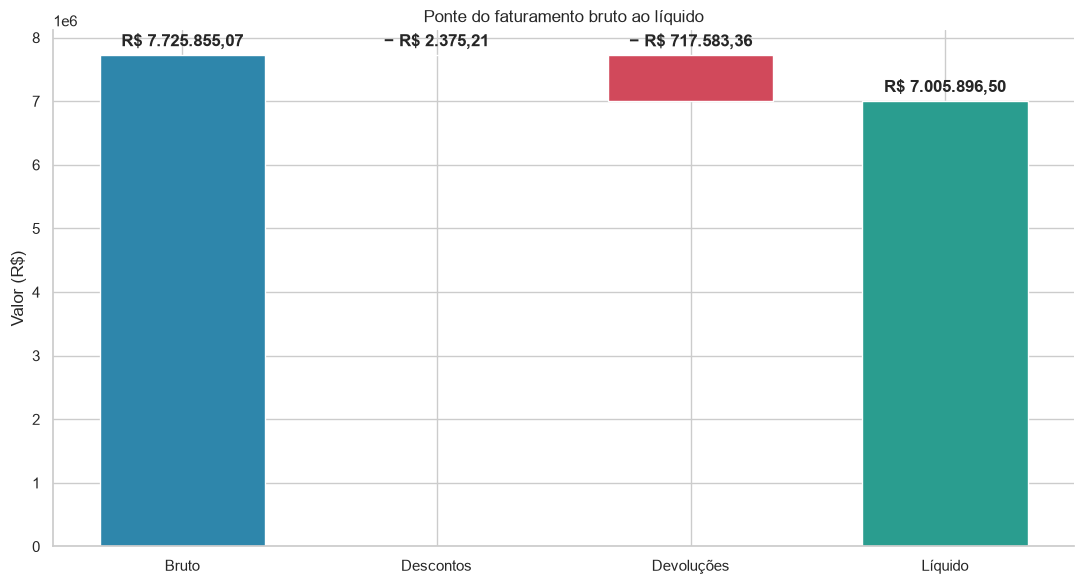

In [29]:
# Ponte entre faturamento bruto e líquido.
valor_descontos_plot = df_item_venda["VL_TOTALDESC"].sum()
apos_descontos = faturamento_bruto - valor_descontos_plot
etapas = ["Bruto", "Descontos", "Devoluções", "Líquido"]
valores = [faturamento_bruto, -valor_descontos_plot, -valor_devolucoes, faturamento_liquido]
bases = [0, apos_descontos, faturamento_liquido, 0]
alturas = [faturamento_bruto, valor_descontos_plot, valor_devolucoes, faturamento_liquido]
cores = ["#2E86AB", "#F4A261", "#D1495B", "#2A9D8F"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(etapas, alturas, bottom=bases, color=cores, width=0.65)
for i, (valor, base, altura) in enumerate(zip(valores, bases, alturas)):
    sinal = "" if i in (0, 3) else "− "
    ax.text(i, base + altura + faturamento_bruto * 0.018, f"{sinal}{format_brl(abs(valor))}", ha="center", fontweight="bold")
ax.set(title="Ponte do faturamento bruto ao líquido", ylabel="Valor (R$)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Valor de descontos

Agora, valor de descontos concedidos nas vendas válidas.

Esse valor considera apenas descontos aplicados às operações classificadas como:

- VENDA
- VENDA CONSUMIDOR FINAL
- VENDA SEM TRANSITO

In [30]:
valor_descontos = df_item_venda["VL_TOTALDESC"].sum()

print(f"Valor de descontos: {format_brl(valor_descontos)}")

Valor de descontos: R$ 2.375,21


Os R$ 133,74 registrados nas devoluções não entram nessa métrica, pois pertencem aos documentos de devolução, não aos descontos originalmente concedidos nas vendas.

## Quantidade faturada

Analisando somente a quantidade vendida nas vendas válidas.

In [31]:
def format_qtd(quantidade):
    return f"{quantidade:,.0f}".replace(",", ".")

quantidade_faturada = df_item_venda["QT_FATURADO"].sum()

quantidade_devolvida = df_item_devolucao["QT_FATURADO"].sum()

quantidade_liquida = (
    quantidade_faturada
    - quantidade_devolvida
)

print(f"Quantidade de itens faturados:\t {format_qtd(quantidade_faturada)}")
print(f"Quantidade devolvida:\t\t {format_qtd(quantidade_devolvida)}")
print(f"Quantidade líquida:\t\t {format_qtd(quantidade_liquida)}")

Quantidade de itens faturados:	 25.110
Quantidade devolvida:		 1.459
Quantidade líquida:		 23.651


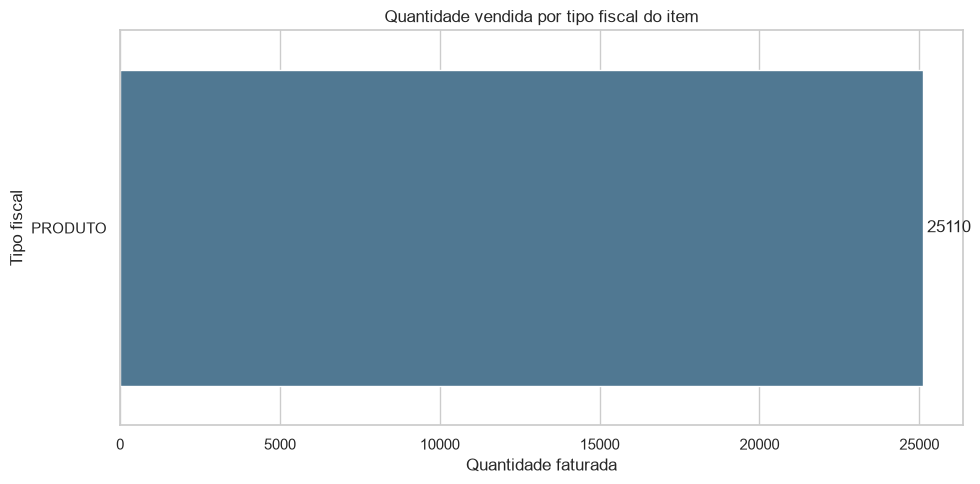

In [32]:
# Composição da quantidade vendida por tipo fiscal do item.
volume_tipo_item = (
    df_item_venda.groupby("TIPO_ITEM_FISCAL", as_index=False, dropna=False)
    .agg(quantidade_faturada=("QT_FATURADO", "sum"))
    .sort_values("quantidade_faturada", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=volume_tipo_item,
    x="quantidade_faturada",
    y="TIPO_ITEM_FISCAL",
    color="#457B9D",
    ax=ax,
)
ax.set(
    title="Quantidade vendida por tipo fiscal do item",
    xlabel="Quantidade faturada",
    ylabel="Tipo fiscal",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

## Quantidade de notas fiscais distintas

In [33]:
quantidade_notas = (
    df_item_venda[CHAVE_NF]
    .drop_duplicates()
    .shape[0]
)

print(
    "Quantidade de notas fiscais distintas:\t",
    format_qtd(quantidade_notas)
)

Quantidade de notas fiscais distintas:	 16.062


In [34]:
# Validando

CHAVE_DOCUMENTO = [
    "CD_EMPRESA",
    "CD_EMPFAT",
    "NR_FATURA",
    "DT_FATURA",
]

quantidade_documentos = (
    df_item_venda[CHAVE_DOCUMENTO]
    .drop_duplicates()
    .shape[0]
)

print("Notas fiscais distintas:\t", format_qtd(quantidade_notas))
print("Documentos/faturas distintas:\t", format_qtd(quantidade_documentos))

Notas fiscais distintas:	 16.062
Documentos/faturas distintas:	 16.062


## Ticket médio por nota fiscal

``` Ticket médio = Faturamento líquido / Quantidade de notas distintas```

In [35]:
ticket_medio = (
    faturamento_liquido / quantidade_notas
    if quantidade_notas > 0
    else 0
)

print(f"Ticket médio por nota fiscal:\t {format_brl(ticket_medio)}")

Ticket médio por nota fiscal:	 R$ 436,18


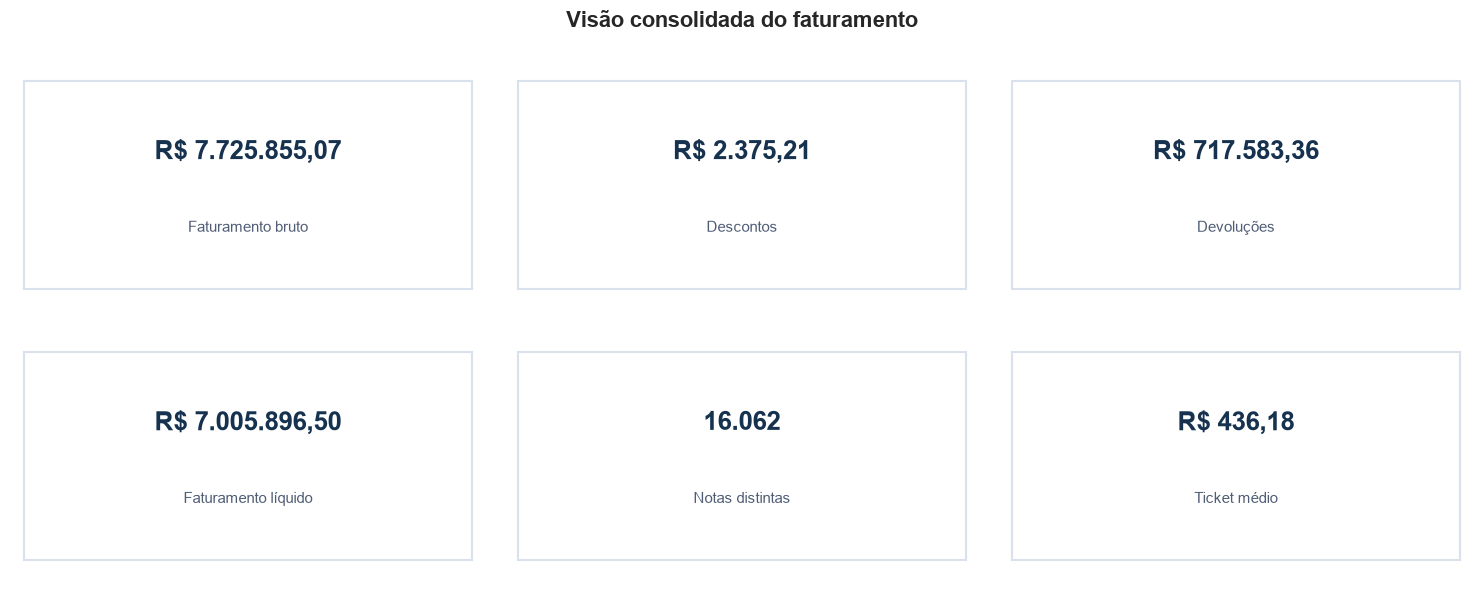

In [36]:
# Painel consolidado dos principais indicadores.
kpis = [
    ("Faturamento bruto", format_brl(faturamento_bruto)),
    ("Descontos", format_brl(valor_descontos)),
    ("Devoluções", format_brl(valor_devolucoes)),
    ("Faturamento líquido", format_brl(faturamento_liquido)),
    ("Notas distintas", format_qtd(quantidade_notas)),
    ("Ticket médio", format_brl(ticket_medio)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax, (titulo, valor) in zip(axes.flat, kpis):
    ax.axis("off")
    ax.text(0.5, 0.62, valor, ha="center", va="center", fontsize=19, fontweight="bold", color="#16324F")
    ax.text(0.5, 0.32, titulo, ha="center", va="center", fontsize=11, color="#4F5D75")
    ax.add_patch(plt.Rectangle((0.03, 0.08), 0.94, 0.82, fill=False, linewidth=1.5, edgecolor="#D9E2EC"))
fig.suptitle("Visão consolidada do faturamento", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Esse cálculo utiliza o faturamento líquido após descontos e devoluções.

In [37]:
ticket_medio_bruto = faturamento_bruto / quantidade_notas

print(f"Ticket médio bruto:\t\t {format_brl(ticket_medio_bruto)}")
print(f"Ticket médio líquido:\t\t {format_brl(ticket_medio)}")

Ticket médio bruto:		 R$ 481,00
Ticket médio líquido:		 R$ 436,18


# Evolução diária do faturamento e análises complementares

In [38]:
evolucao_vendas = (
    df_item_venda
    .groupby("DT_EMISSAO", as_index=False)
    .agg(
        faturamento_bruto=("VL_TOTALBRUTO", "sum"),
        descontos=("VL_TOTALDESC", "sum"),
        faturamento_apos_descontos=("VL_TOTALLIQUIDO", "sum"),
    )
)

evolucao_devolucoes = (
    df_item_devolucao
    .groupby("DT_EMISSAO", as_index=False)
    .agg(
        devolucoes=("VL_TOTALLIQUIDO", "sum")
    )
)

evolucao_diaria = (
    evolucao_vendas
    .merge(
        evolucao_devolucoes,
        on="DT_EMISSAO",
        how="outer"
    )
    .fillna(0)
    .sort_values("DT_EMISSAO")
)

evolucao_diaria["faturamento_liquido"] = (
    evolucao_diaria["faturamento_apos_descontos"]
    - evolucao_diaria["devolucoes"]
)

evolucao_diaria

In [39]:
print(
    "Faturamento bruto:\t",
    format_brl(evolucao_diaria["faturamento_bruto"].sum())
)

print(
    "Descontos:\t\t",
    format_brl(evolucao_diaria["descontos"].sum())
)

print(
    "Devoluções:\t\t",
    format_brl(evolucao_diaria["devolucoes"].sum())
)

print(
    "Faturamento líquido:\t",
    format_brl(evolucao_diaria["faturamento_liquido"].sum())
)

Faturamento bruto:	 R$ 7.725.855,07
Descontos:		 R$ 2.375,21
Devoluções:		 R$ 717.583,36
Faturamento líquido:	 R$ 7.005.896,50


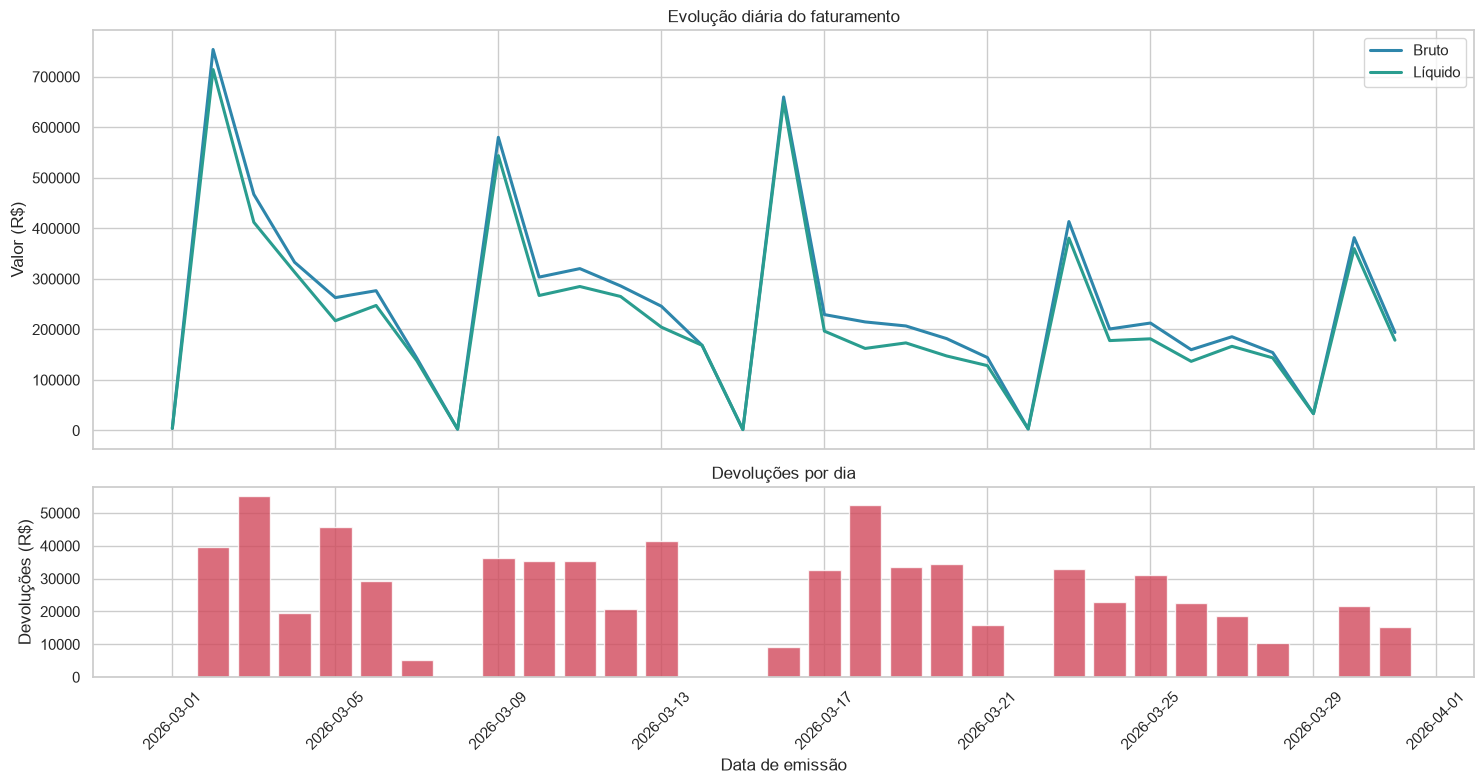

In [40]:
# Evolução diária: linhas para faturamento e barras para devoluções.
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]},
)
sns.lineplot(
    data=evolucao_diaria,
    x="DT_EMISSAO",
    y="faturamento_bruto",
    label="Bruto",
    color="#2E86AB",
    linewidth=2.2,
    ax=ax1,
)
sns.lineplot(
    data=evolucao_diaria,
    x="DT_EMISSAO",
    y="faturamento_liquido",
    label="Líquido",
    color="#2A9D8F",
    linewidth=2.2,
    ax=ax1,
)
ax1.set(title="Evolução diária do faturamento", xlabel="", ylabel="Valor (R$)")
ax1.legend()

ax2.bar(
    evolucao_diaria["DT_EMISSAO"],
    evolucao_diaria["devolucoes"],
    color="#D1495B",
    alpha=0.8,
)
ax2.set(title="Devoluções por dia", xlabel="Data de emissão", ylabel="Devoluções (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Faturamento por empresa

Utilizando ```CD_EMPFAT``` como empresa faturadora.

In [41]:
faturamento_vendas_empresa = (
    df_item_venda
    .groupby("CD_EMPFAT", as_index=False)
    .agg(
        faturamento_bruto=("VL_TOTALBRUTO", "sum"),
        descontos=("VL_TOTALDESC", "sum"),
        faturamento_apos_descontos=("VL_TOTALLIQUIDO", "sum"),
    )
)

devolucoes_empresa = (
    df_item_devolucao
    .groupby("CD_EMPFAT", as_index=False)
    .agg(
        devolucoes=("VL_TOTALLIQUIDO", "sum")
    )
)

faturamento_empresa = (
    faturamento_vendas_empresa
    .merge(
        devolucoes_empresa,
        on="CD_EMPFAT",
        how="outer"
    )
    .fillna(0)
)

faturamento_empresa["faturamento_liquido"] = (
    faturamento_empresa["faturamento_apos_descontos"]
    - faturamento_empresa["devolucoes"]
)

faturamento_empresa = (
    faturamento_empresa
    .sort_values(
        "faturamento_liquido",
        ascending=False
    )
    .reset_index(drop=True)
)

faturamento_empresa.T

In [42]:
print(
    "Código empresa:\t\t",
    faturamento_empresa['CD_EMPFAT'].values
)

print(
    "Faturamento bruto:\t",
    format_brl(faturamento_empresa["faturamento_bruto"].sum())
)

print(
    "Descontos:\t\t",
    format_brl(faturamento_empresa["descontos"].sum())
)

print(
    "Devoluções:\t\t",
    format_brl(faturamento_empresa["devolucoes"].sum())
)

print(
    "Faturamento líquido:\t",
    format_brl(faturamento_empresa["faturamento_liquido"].sum())
)

Código empresa:		 [6]
Faturamento bruto:	 R$ 7.725.855,07
Descontos:		 R$ 2.375,21
Devoluções:		 R$ 717.583,36
Faturamento líquido:	 R$ 7.005.896,50


## Principais produtos por faturamento

Como a métrica é por produto, é preciso o filtro TIPO_ITEM_FISCAL == "PRODUTO" nas vendas.

As devoluções já são integralmente de produtos.

In [43]:
# Aplicando filtros
df_produto_venda = df_item_venda[
    df_item_venda["TIPO_ITEM_FISCAL"].eq("PRODUTO")
].copy()

df_produto_devolucao = df_item_devolucao[
    df_item_devolucao["TIPO_ITEM_FISCAL"].eq("PRODUTO")
].copy()

In [44]:
# Faturamento das vendas por produto
faturamento_produto_venda = (
    df_produto_venda
    .groupby(
        ["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        as_index=False,
        dropna=False
    )
    .agg(
        faturamento_bruto=("VL_TOTALBRUTO", "sum"),
        descontos=("VL_TOTALDESC", "sum"),
        faturamento_apos_descontos=("VL_TOTALLIQUIDO", "sum"),
    )
)

In [45]:
# Devoluções por produto
devolucao_produto = (
    df_produto_devolucao
    .groupby(
        ["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        as_index=False,
        dropna=False
    )
    .agg(
        devolucoes=("VL_TOTALLIQUIDO", "sum")
    )
)

In [46]:
# Calculando faturamento liquido
faturamento_por_produto = (
    faturamento_produto_venda
    .merge(
        devolucao_produto,
        on=["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        how="outer"
    )
    .fillna(0)
)

faturamento_por_produto["faturamento_liquido"] = (
    faturamento_por_produto["faturamento_apos_descontos"]
    - faturamento_por_produto["devolucoes"]
)

faturamento_por_produto = (
    faturamento_por_produto
    .sort_values(
        "faturamento_liquido",
        ascending=False
    )
    .reset_index(drop=True)
)

In [47]:
top_10_produtos_faturamento = (
    faturamento_por_produto
    .head(10)
)

top_10_produtos_faturamento

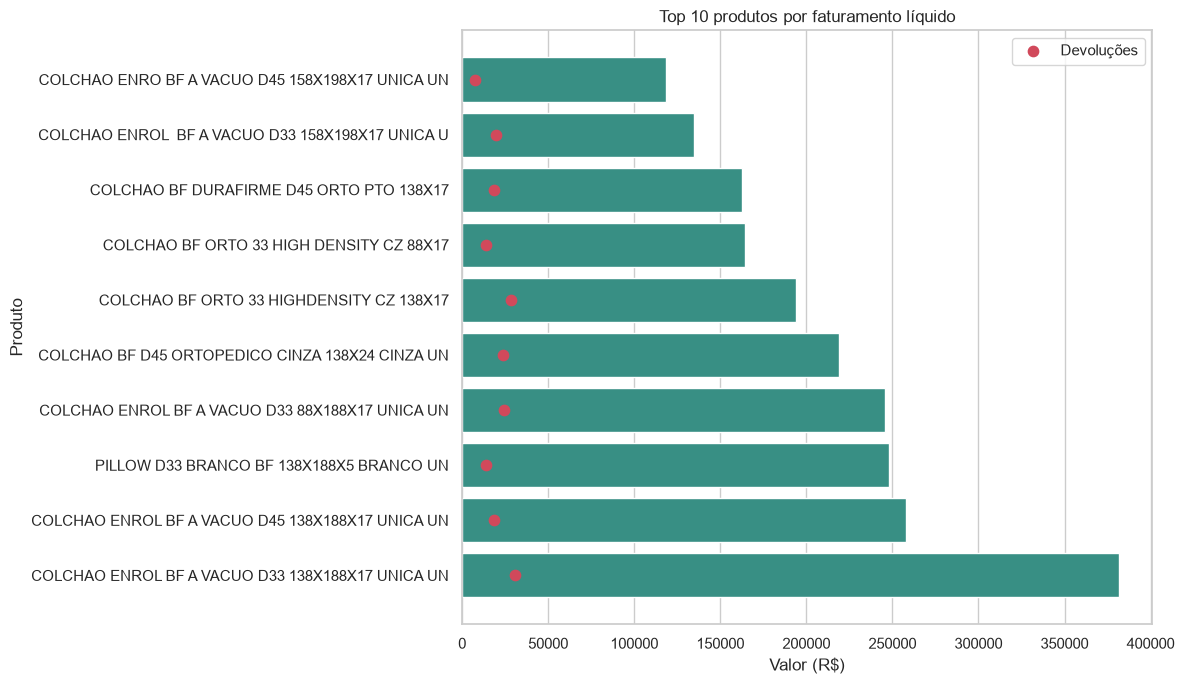

In [48]:
# Top 10 produtos: faturamento líquido e valor devolvido.
plot_produtos_fat = top_10_produtos_faturamento.copy()
plot_produtos_fat["rotulo"] = plot_produtos_fat["DS_PRODUTO"].str.slice(0, 48)
plot_produtos_fat = plot_produtos_fat.sort_values("faturamento_liquido")

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_produtos_fat,
    x="faturamento_liquido",
    y="rotulo",
    color="#2A9D8F",
    ax=ax,
)
ax.scatter(
    plot_produtos_fat["devolucoes"],
    plot_produtos_fat["rotulo"],
    color="#D1495B",
    s=55,
    label="Devoluções",
    zorder=3,
)
ax.set(
    title="Top 10 produtos por faturamento líquido",
    xlabel="Valor (R$)",
    ylabel="Produto",
)
ax.legend()
plt.tight_layout()
plt.show()

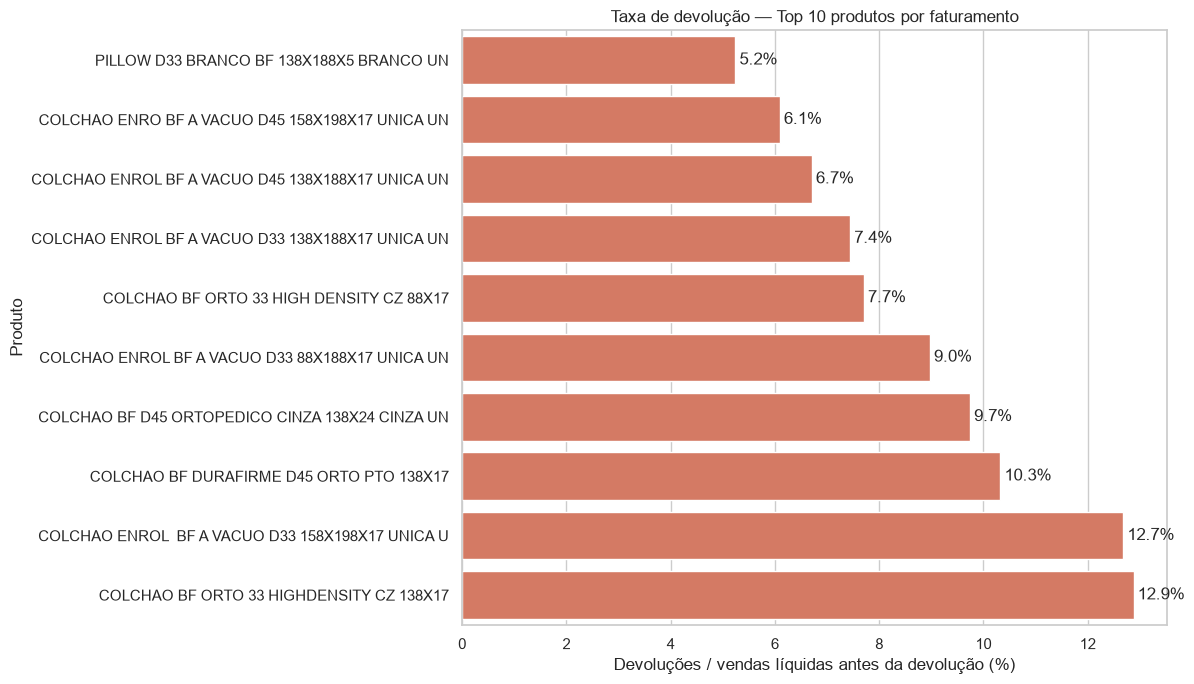

In [49]:
# Taxa de devolução dos produtos líderes em faturamento.
taxa_devolucao_produto = top_10_produtos_faturamento.copy()
taxa_devolucao_produto["taxa_devolucao"] = np.where(
    taxa_devolucao_produto["faturamento_apos_descontos"].ne(0),
    taxa_devolucao_produto["devolucoes"] / taxa_devolucao_produto["faturamento_apos_descontos"] * 100,
    0,
)
taxa_devolucao_produto["rotulo"] = taxa_devolucao_produto["DS_PRODUTO"].str.slice(0, 48)
taxa_devolucao_produto = taxa_devolucao_produto.sort_values("taxa_devolucao")

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=taxa_devolucao_produto,
    x="taxa_devolucao",
    y="rotulo",
    color="#E76F51",
    ax=ax,
)
ax.set(
    title="Taxa de devolução — Top 10 produtos por faturamento",
    xlabel="Devoluções / vendas líquidas antes da devolução (%)",
    ylabel="Produto",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()

## Principais produtos por quantidade faturada

Visualizando apenas itens classificados como PRODUTO, calcula-se:

- Quantidade vendida.
- Quantidade devolvida.
- Quantidade líquida.

In [50]:
quantidade_produto_venda = (
    df_produto_venda
    .groupby(
        # ["CD_PRODUTO", "DS_PRODUTO",],
        ["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        as_index=False,
        dropna=False
    )
    .agg(
        quantidade_faturada=("QT_FATURADO", "sum")
    )
)

In [51]:
quantidade_produto_devolucao = (
    df_produto_devolucao
    .groupby(
        # ["CD_PRODUTO", "DS_PRODUTO"],
        ["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        as_index=False,
        dropna=False
    )
    .agg(
        quantidade_devolvida=("QT_FATURADO", "sum")
    )
)

In [52]:
quantidade_por_produto = (
    quantidade_produto_venda
    .merge(
        quantidade_produto_devolucao,
        # on=["CD_PRODUTO", "DS_PRODUTO",],
        on=["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        how="outer"
    )
    .fillna(0)
)

In [53]:
quantidade_por_produto["quantidade_liquida"] = (
    quantidade_por_produto["quantidade_faturada"]
    - quantidade_por_produto["quantidade_devolvida"]
)

quantidade_por_produto = (
    quantidade_por_produto
    .sort_values(
        "quantidade_liquida",
        ascending=False
    )
    .reset_index(drop=True)
)

In [54]:
top_10_produtos_quantidade = quantidade_por_produto.head(10)

top_10_produtos_quantidade

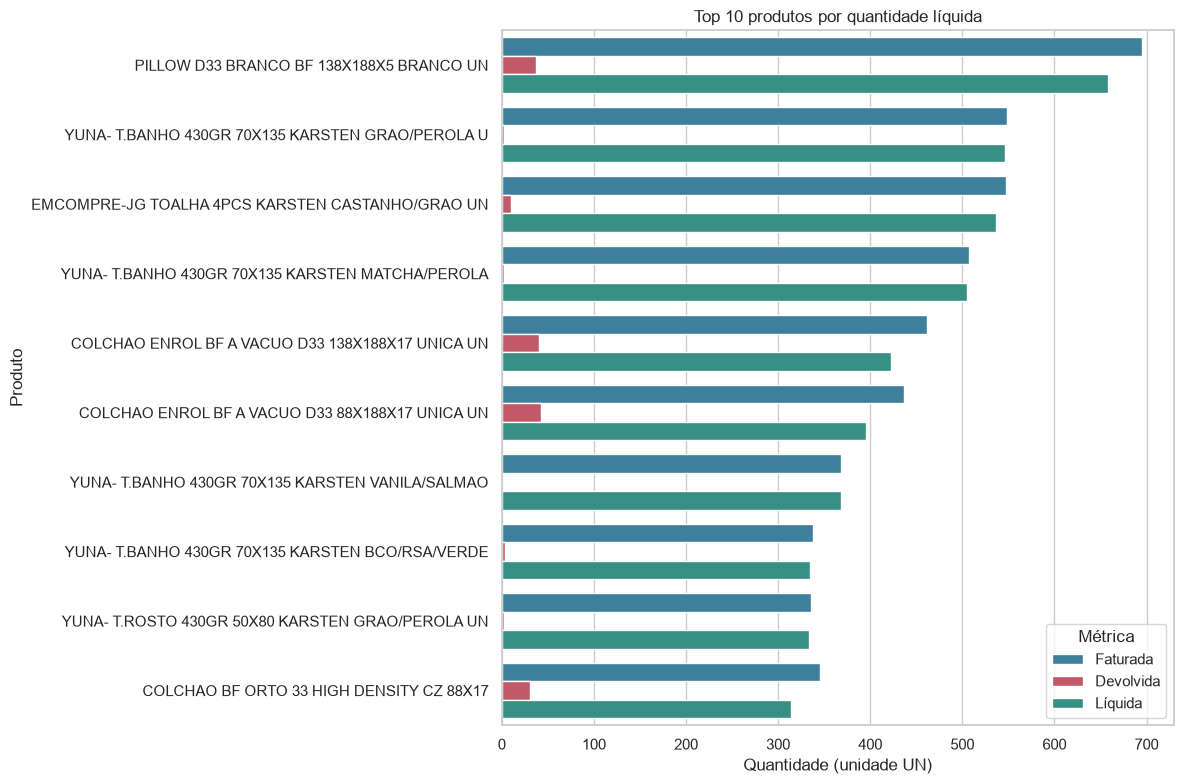

In [55]:
# Top 10 produtos: quantidade faturada, devolvida e líquida.
plot_produtos_qtd = top_10_produtos_quantidade.copy()
plot_produtos_qtd["rotulo"] = plot_produtos_qtd["DS_PRODUTO"].str.slice(0, 48)
plot_produtos_qtd = plot_produtos_qtd.melt(
    id_vars=["rotulo"],
    value_vars=["quantidade_faturada", "quantidade_devolvida", "quantidade_liquida"],
    var_name="metrica",
    value_name="quantidade",
)
plot_produtos_qtd["metrica"] = plot_produtos_qtd["metrica"].map({
    "quantidade_faturada": "Faturada",
    "quantidade_devolvida": "Devolvida",
    "quantidade_liquida": "Líquida",
})

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=plot_produtos_qtd,
    x="quantidade",
    y="rotulo",
    hue="metrica",
    palette={"Faturada": "#2E86AB", "Devolvida": "#D1495B", "Líquida": "#2A9D8F"},
    ax=ax,
)
ax.set(
    title="Top 10 produtos por quantidade líquida",
    xlabel="Quantidade (unidade UN)",
    ylabel="Produto",
)
ax.legend(title="Métrica")
plt.tight_layout()
plt.show()

In [56]:
top_10_produtos_quantidade = quantidade_por_produto.head(10)

top_10_produtos_quantidade

## Análise final

In [57]:
# Maior e menor faturamento diário
maior_dia = evolucao_diaria.loc[
    evolucao_diaria["faturamento_liquido"].idxmax()
]

menor_dia = evolucao_diaria.loc[
    evolucao_diaria["faturamento_liquido"].idxmin()
]

print("Maior dia:")
print(maior_dia)

print("\nMenor dia:")
print(menor_dia)

Maior dia:
DT_EMISSAO                    2026-03-02 00:00:00
faturamento_bruto                       754054.92
descontos                                   109.9
faturamento_apos_descontos              753945.02
devolucoes                               39695.28
faturamento_liquido                     714249.74
Name: 1, dtype: object

Menor dia:
DT_EMISSAO                    2026-03-15 00:00:00
faturamento_bruto                          1728.9
descontos                                     0.0
faturamento_apos_descontos                 1728.9
devolucoes                                    0.0
faturamento_liquido                        1728.9
Name: 14, dtype: object


In [58]:
# Concentração dos cinco e dez principais produtos
total_produtos = faturamento_por_produto["faturamento_liquido"].sum()

participacao_top5 = (
    faturamento_por_produto
    .head(5)["faturamento_liquido"]
    .sum()
    / total_produtos
)

participacao_top10 = (
    faturamento_por_produto
    .head(10)["faturamento_liquido"]
    .sum()
    / total_produtos
)

print(f"Participação do Top 5: {participacao_top5:.2%}")
print(f"Participação do Top 10: {participacao_top10:.2%}")

Participação do Top 5: 19.31%
Participação do Top 10: 30.36%


In [59]:
# Participação do faturamento por empresa
faturamento_empresa["participacao"] = (
    faturamento_empresa["faturamento_liquido"]
    / faturamento_empresa["faturamento_liquido"].sum()
)

faturamento_empresa[
    ["CD_EMPFAT", "faturamento_liquido", "participacao"]
]

#### Produtos com maior taxa de devolução

In [60]:
analise_devolucao_produto = (
    faturamento_por_produto[
        [
            "CD_PRODUTO",
            "DS_PRODUTO",
            "CD_ESPECIE",
            "faturamento_apos_descontos",
            "devolucoes",
            "faturamento_liquido",
        ]
    ]
    .merge(
        quantidade_por_produto[
            [
                "CD_PRODUTO",
                "DS_PRODUTO",
                "CD_ESPECIE",
                "quantidade_faturada",
                "quantidade_devolvida",
                "quantidade_liquida",
            ]
        ],
        on=["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        how="outer",
    )
    .fillna(0)
)

analise_devolucao_produto["taxa_devolucao_valor"] = (
    analise_devolucao_produto["devolucoes"]
    .div(
        analise_devolucao_produto[
            "faturamento_apos_descontos"
        ].replace(0, pd.NA)
    )
)

analise_devolucao_produto["taxa_devolucao_quantidade"] = (
    analise_devolucao_produto["quantidade_devolvida"]
    .div(
        analise_devolucao_produto[
            "quantidade_faturada"
        ].replace(0, pd.NA)
    )
)

top_produtos_devolucao = (
    analise_devolucao_produto
    .query("devolucoes > 0")
    .sort_values("devolucoes", ascending=False)
    .head(10)
)

top_produtos_devolucao.style.format(
    {
        "faturamento_apos_descontos": format_brl,
        "devolucoes": format_brl,
        "taxa_devolucao_valor": "{:.2%}",
        "taxa_devolucao_quantidade": "{:.2%}",
    }
)

,CD_PRODUTO,DS_PRODUTO,CD_ESPECIE,faturamento_apos_descontos,devolucoes,faturamento_liquido,quantidade_faturada,quantidade_devolvida,quantidade_liquida,taxa_devolucao_valor,taxa_devolucao_quantidade
249,304940,COLCHAO ENROL BF A VACUO D33 138X188X17 UNICA UN,UN,"R$ 412.581,12","R$ 30.699,38",381881.740000,462.000000,40.000000,422.000000,7.44%,8.66%
538,372128,COLCHAO BF ORTO 33 HIGHDENSITY CZ 138X17,UN,"R$ 222.605,91","R$ 28.668,35",193937.560000,296.000000,45.000000,251.000000,12.88%,15.20%
250,304941,COLCHAO ENROL BF A VACUO D33 88X188X17 UNICA UN,UN,"R$ 270.016,10","R$ 24.220,94",245795.160000,437.000000,42.000000,395.000000,8.97%,9.61%
654,383935,COLCHAO BF D45 ORTOPEDICO CINZA 138X24 CINZA UN,UN,"R$ 242.692,28","R$ 23.638,13",219054.150000,228.000000,26.000000,202.000000,9.74%,11.40%
567,373754,COLCHAO BF PREMIUM SLEEP 158X38 PT TF UNICO UN,UN,"R$ 68.279,67","R$ 21.994,19",46285.480000,30.000000,12.000000,18.000000,32.21%,40.00%
248,304939,COLCHAO ENROL BF A VACUO D33 158X198X17 UNICA UN,UN,"R$ 154.460,29","R$ 19.587,81",134872.480000,139.000000,19.000000,120.000000,12.68%,13.67%
648,383653,COLCHAO BF DURAFIRME D45 ORTO PTO 138X17,UN,"R$ 181.035,72","R$ 18.689,82",162345.900000,230.000000,27.000000,203.000000,10.32%,11.74%
252,304943,COLCHAO ENROL BF A VACUO D45 138X188X17 UNICA UN,UN,"R$ 276.489,95","R$ 18.541,01",257948.940000,265.000000,19.000000,246.000000,6.71%,7.17%
568,373755,COLCHAO BF PREMIUM SLEEP 138X38 PT TF UNICO UN,UN,"R$ 120.421,95","R$ 14.817,05",105604.900000,62.000000,9.000000,53.000000,12.30%,14.52%
541,372131,COLCHAO BF ORTO 33 HIGH DENSITY CZ 88X17,UN,"R$ 178.351,18","R$ 13.738,99",164612.190000,345.000000,31.000000,314.000000,7.70%,8.99%


#### Diferença entre volume vendido e faturamento gerado

In [61]:
analise_volume_faturamento = (
    faturamento_por_produto[
        [
            "CD_PRODUTO",
            "DS_PRODUTO",
            "CD_ESPECIE",
            "faturamento_liquido",
        ]
    ]
    .merge(
        quantidade_por_produto[
            [
                "CD_PRODUTO",
                "DS_PRODUTO",
                "CD_ESPECIE",
                "quantidade_liquida",
            ]
        ],
        on=["CD_PRODUTO", "DS_PRODUTO", "CD_ESPECIE"],
        how="outer",
    )
    .fillna(0)
)

analise_volume_faturamento["valor_liquido_por_unidade"] = (
    analise_volume_faturamento["faturamento_liquido"]
    .div(
        analise_volume_faturamento[
            "quantidade_liquida"
        ].replace(0, pd.NA)
    )
)

analise_volume_faturamento["ranking_faturamento"] = (
    analise_volume_faturamento["faturamento_liquido"]
    .rank(method="min", ascending=False)
)

analise_volume_faturamento["ranking_quantidade"] = (
    analise_volume_faturamento["quantidade_liquida"]
    .rank(method="min", ascending=False)
)

analise_volume_faturamento["diferenca_ranking"] = (
    analise_volume_faturamento["ranking_quantidade"]
    - analise_volume_faturamento["ranking_faturamento"]
)

##### Produtos com alto faturamento e menor volume

In [62]:
produtos_alto_valor_baixo_volume = (
    analise_volume_faturamento
    .query("quantidade_liquida > 0")
    .sort_values("diferenca_ranking", ascending=False)
    .head(10)
)

produtos_alto_valor_baixo_volume[
    [
        "CD_PRODUTO",
        "DS_PRODUTO",
        "CD_ESPECIE",
        "faturamento_liquido",
        "quantidade_liquida",
        "valor_liquido_por_unidade",
        "ranking_faturamento",
        "ranking_quantidade",
    ]
]

##### Produtos com alto volume e menor contribuição financeira

In [63]:
produtos_alto_volume_baixo_valor = (
    analise_volume_faturamento
    .query("quantidade_liquida > 0")
    .sort_values("diferenca_ranking", ascending=True)
    .head(10)
)

produtos_alto_volume_baixo_valor[
    [
        "CD_PRODUTO",
        "DS_PRODUTO",
        "CD_ESPECIE",
        "faturamento_liquido",
        "quantidade_liquida",
        "valor_liquido_por_unidade",
        "ranking_faturamento",
        "ranking_quantidade",
    ]
]

##### Concentração e volatilidade do faturamento diário

In [64]:
total_faturamento_periodo = (
    evolucao_diaria["faturamento_liquido"].sum()
)

top_5_dias = (
    evolucao_diaria
    .nlargest(5, "faturamento_liquido")
    [
        [
            "DT_EMISSAO",
            "faturamento_bruto",
            "devolucoes",
            "faturamento_liquido",
        ]
    ]
)

participacao_top_5_dias = (
    top_5_dias["faturamento_liquido"].sum()
    / total_faturamento_periodo
)

media_diaria = evolucao_diaria["faturamento_liquido"].mean()
mediana_diaria = evolucao_diaria["faturamento_liquido"].median()
desvio_padrao_diario = evolucao_diaria["faturamento_liquido"].std()

coeficiente_variacao = (
    desvio_padrao_diario / media_diaria
    if media_diaria != 0
    else pd.NA
)

print(
    "Participação dos 5 maiores dias no faturamento:",
    f"{participacao_top_5_dias:.2%}",
)

print(
    "Faturamento líquido médio diário:",
    format_brl(media_diaria),
)

print(
    "Faturamento líquido mediano diário:",
    format_brl(mediana_diaria),
)

print(
    "Coeficiente de variação diário:",
    f"{coeficiente_variacao:.2%}",
)

display(top_5_dias)

Participação dos 5 maiores dias no faturamento: 38.56%
Faturamento líquido médio diário: R$ 225.996,66
Faturamento líquido mediano diário: R$ 178.692,50
Coeficiente de variação diário: 76.94%



A análise considerou somente notas fiscais efetivadas e operações classificadas como venda. O faturamento líquido foi calculado após a dedução dos descontos e das devoluções.

### 1. Resultado geral do faturamento

O faturamento bruto do período foi de **R$ 7.725.855,07**, enquanto o faturamento líquido alcançou **R$ 7.005.896,50**.

A diferença foi de **R$ 719.958,57**, representando uma redução de **9,32%** sobre o faturamento bruto.

### 2. As devoluções são o principal ponto de atenção

Os descontos totalizaram apenas **R$ 2.375,21**, equivalentes a **0,03% do faturamento bruto**.

As devoluções somaram **R$ 717.583,36**, correspondendo a **9,29% do faturamento bruto**. Portanto, praticamente toda a redução do faturamento decorreu das devoluções, e não da concessão de descontos.

Foram faturadas **25.110 unidades** e devolvidas **1.459 unidades**, resultando em uma quantidade líquida de **23.651 unidades**.

Embora as devoluções representem **5,81% da quantidade vendida**, elas equivalem a **9,29% do valor faturado**, indicando maior concentração em produtos de valor elevado.

### 3. Alguns produtos apresentam taxas críticas de devolução

Foram identificados produtos com taxas de devolução relevantes.

O produto `373754 — COLCHAO BF PREMIUM SLEEP 158X38 PT TF` apresentou devolução de:

* **40,00% da quantidade faturada**;
* **32,21% do valor vendido**.

O produto `372128 — COLCHAO BF ORTO 33 HIGHDENSITY` apresentou:

* **15,20% de devolução em quantidade**;
* **12,88% de devolução em valor**.

Esses produtos devem ser priorizados em uma análise de causa-raiz, considerando qualidade, logística, avarias, especificação do pedido e perfil dos clientes.

### 4. O faturamento diário apresenta elevada oscilação

O maior faturamento líquido diário ocorreu em **2 de março de 2026**, com **R$ 714.249,74**.

O menor faturamento ocorreu em **15 de março de 2026**, com **R$ 1.728,90**.

Os cinco melhores dias concentraram **38,56% do faturamento líquido total**, demonstrando dependência relevante de poucos dias de maior movimentação.

O faturamento líquido médio diário foi de **R$ 225.996,66**, enquanto a mediana foi de **R$ 178.692,50**. O coeficiente de variação foi de **76,94%**, indicando elevada instabilidade diária.

Apesar disso, não houve dias com faturamento líquido negativo.

### 5. O faturamento está relativamente diversificado entre produtos

Os cinco produtos com maior faturamento líquido representaram **19,31% do total**, enquanto os dez principais representaram **30,36%**.

Isso significa que aproximadamente **69,64% do faturamento está distribuído entre produtos fora do Top 10**, indicando baixa dependência de um número reduzido de itens.

### 6. Volume vendido e faturamento devem ser analisados separadamente

Produtos com maior quantidade vendida nem sempre são os maiores geradores de faturamento.

Itens têxteis e produtos de menor valor apresentaram maior giro, mas baixa contribuição financeira por unidade. Em contrapartida, determinados colchões geraram valores unitários superiores a **R$ 7 mil**, mesmo com apenas uma unidade vendida.

As decisões comerciais e de estoque devem considerar conjuntamente:

* quantidade vendida;
* faturamento;
* valor médio por unidade;
* margem;
* taxa de devolução.

### 7. As vendas estão concentradas em operações para não contribuintes

As operações classificadas como `VENDA NAO CONTRIBUINTE` representaram aproximadamente **89,93% do faturamento bruto**.

As operações classificadas como `VENDA` corresponderam a **8,49%**, enquanto `VENDA SEM TRANSITO` representou **1,58%**.

Esse perfil deve ser considerado nas análises comerciais e tributárias. A classificação como não contribuinte, entretanto, não significa necessariamente consumidor final, devendo ser confirmada com os dados cadastrais dos clientes.

### 8. O ticket médio foi reduzido principalmente pelas devoluções

O ticket médio bruto foi de **R$ 481,00 por nota fiscal**, enquanto o ticket médio líquido foi de **R$ 436,18**.

A diferença foi de **R$ 44,82 por nota**, equivalente a uma redução de **9,32%**.

Como os descontos foram pouco representativos, essa redução decorreu essencialmente das devoluções.

### 9. O conjunto analisado contém apenas uma empresa faturadora

Todo o faturamento foi associado ao código `CD_EMPFAT = 6`.

Portanto, a base atual não permite comparar o desempenho das diferentes empresas do grupo. É necessário confirmar se:

* a extração foi limitada a uma empresa;
* as demais empresas utilizam outro código;
* `CD_EMPRESA` representa melhor as unidades do grupo;
* `CD_EMPFAT` identifica somente a empresa central de faturamento.

# Conclusão

O principal risco identificado é o volume de devoluções, responsável por praticamente toda a diferença entre o faturamento bruto e o líquido.

As prioridades recomendadas são:

1. identificar os produtos e clientes que concentram as devoluções;
2. investigar as causas operacionais e comerciais dos retornos;
3. acompanhar produtos com taxas de devolução superiores a 10%;
4. avaliar a elevada oscilação diária do faturamento;
5. validar o campo correto para identificar as diferentes empresas do grupo.

A redução das devoluções apresenta potencial de impacto financeiro significativamente superior a qualquer ação relacionada aos descontos comerciais.
